In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv('train.csv')

#EDA

<Axes: >

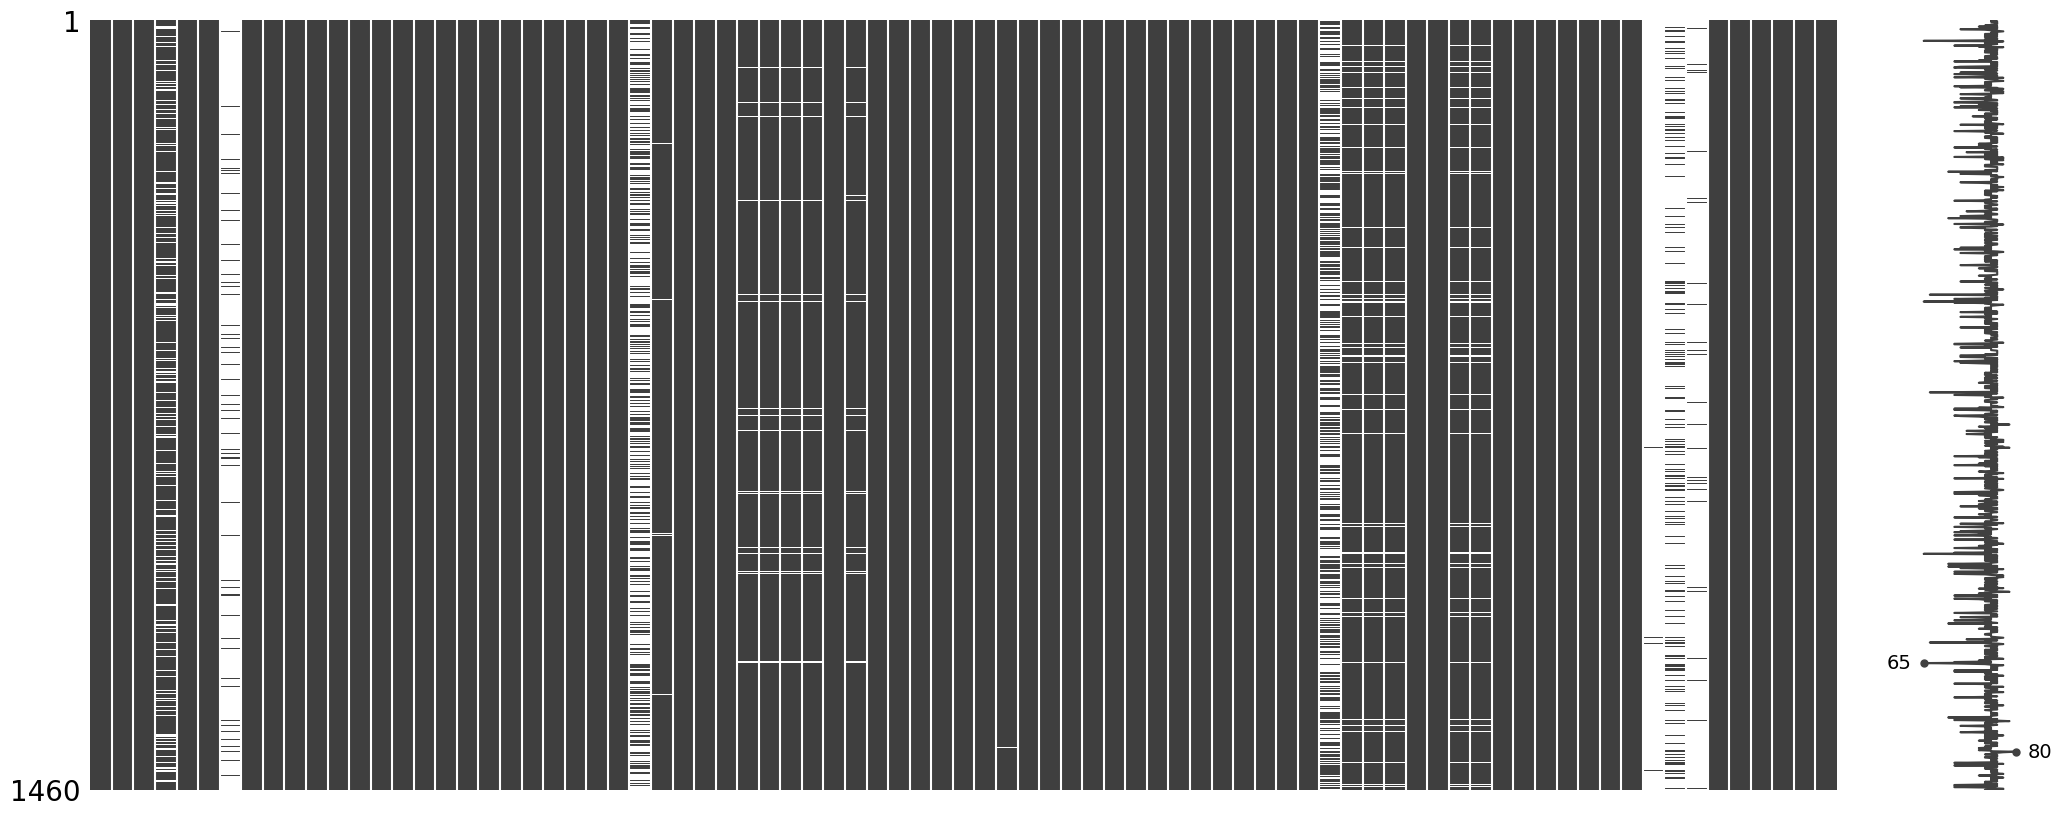

In [3]:
msno.matrix(df)

In [4]:
df.shape

(1460, 81)

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
display(df.isnull().sum().sort_values(ascending=False))

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [10]:
null_percentages = df.isnull().sum() / len(df) * 100
columns_with_high_nulls = null_percentages[null_percentages >= 40].sort_values(ascending=False)
display(columns_with_high_nulls)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274


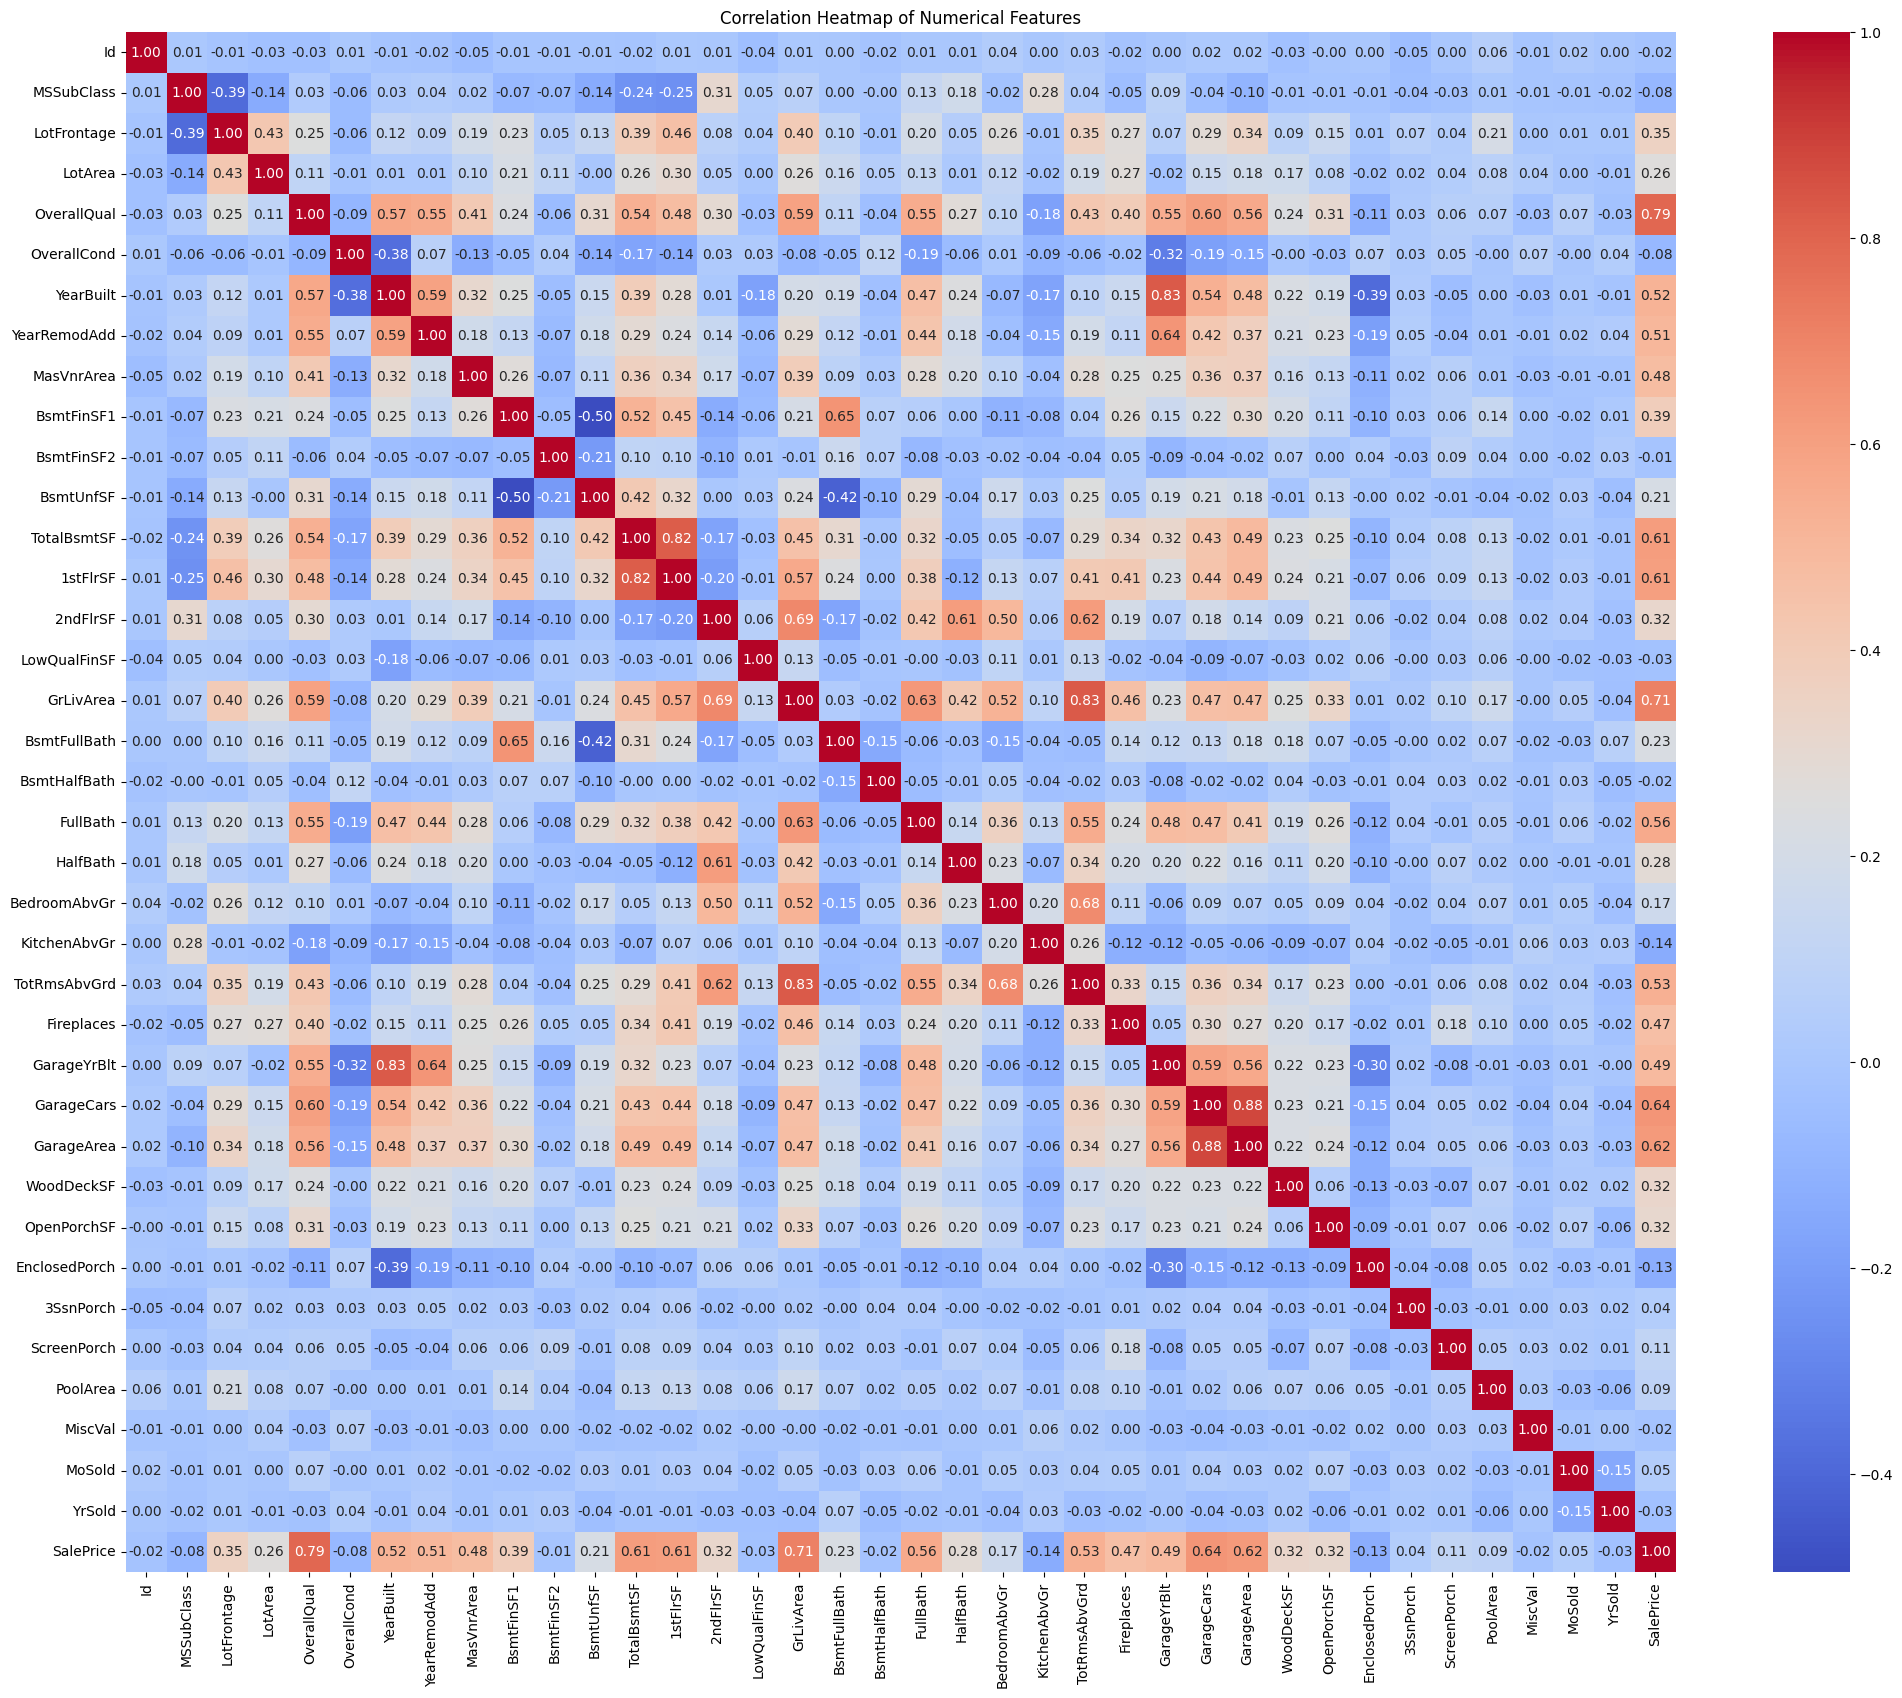

In [11]:
plt.figure(figsize=(25, 20))

sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

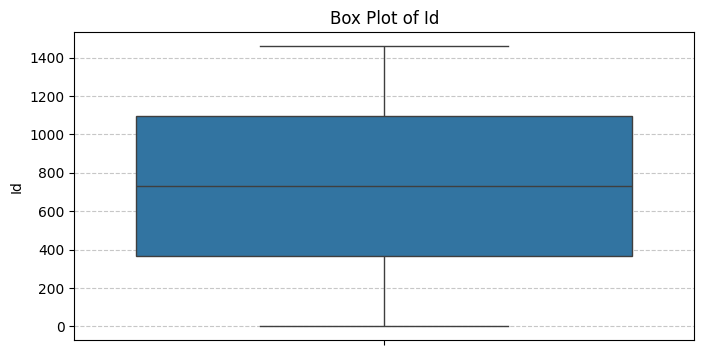

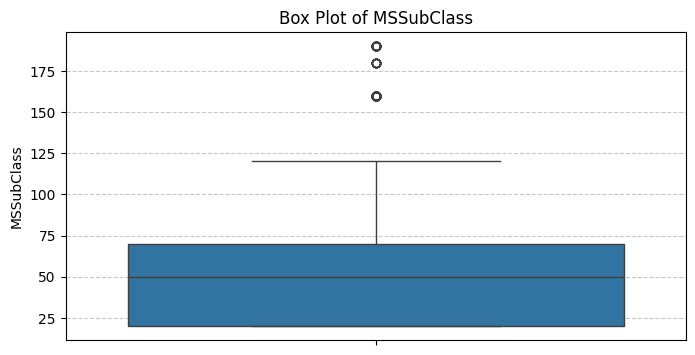

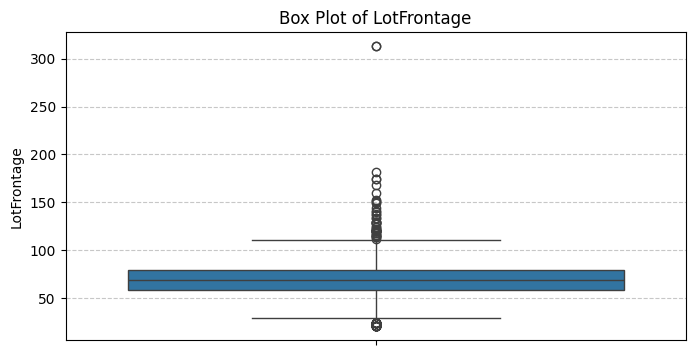

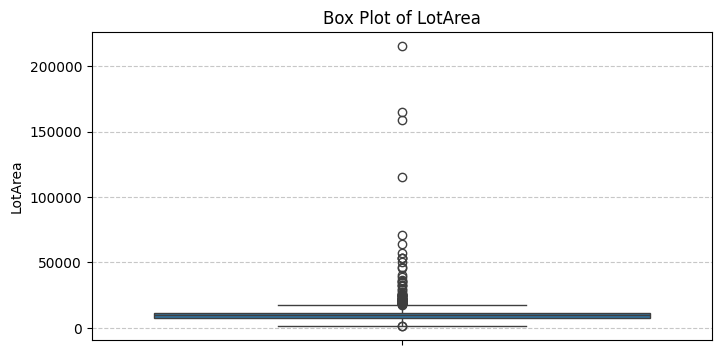

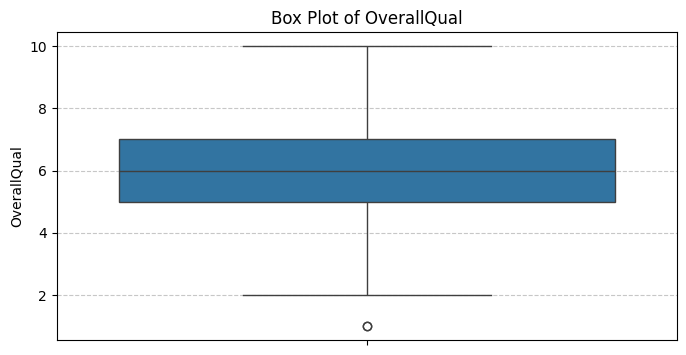

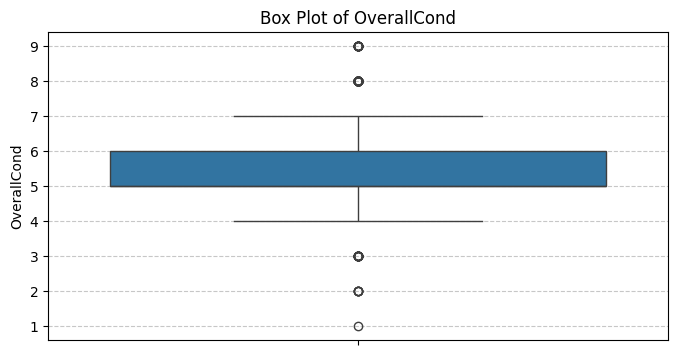

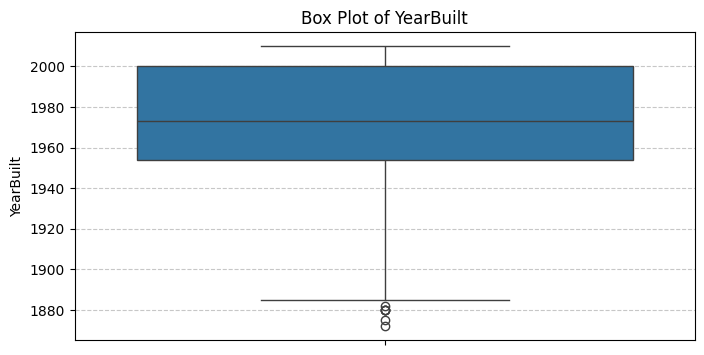

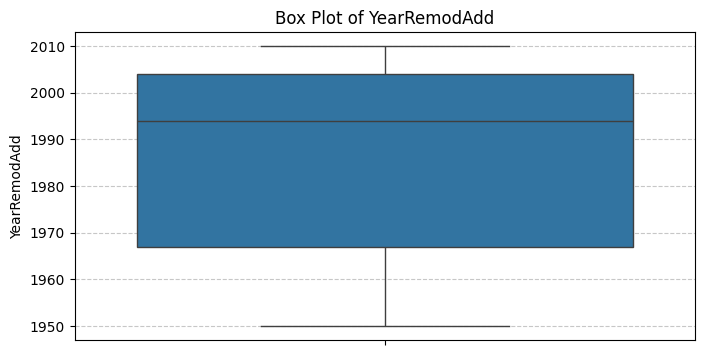

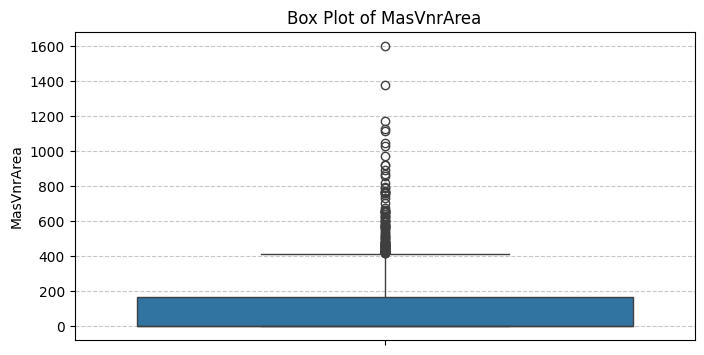

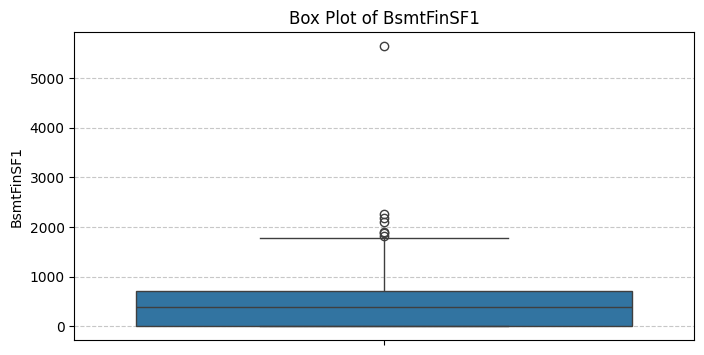

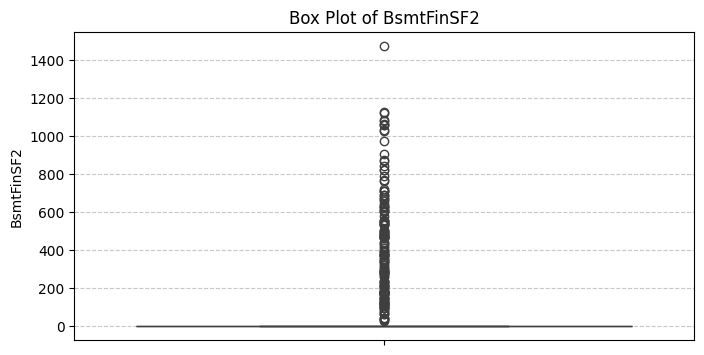

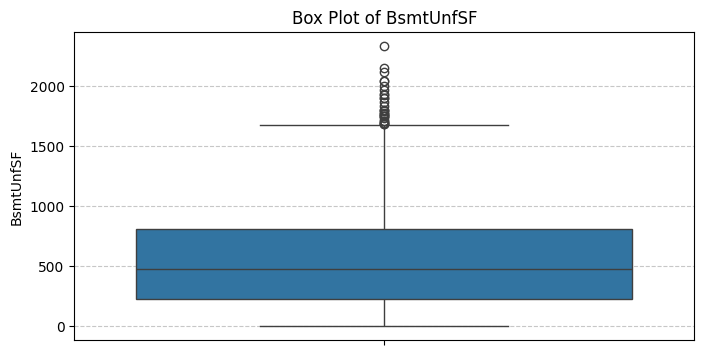

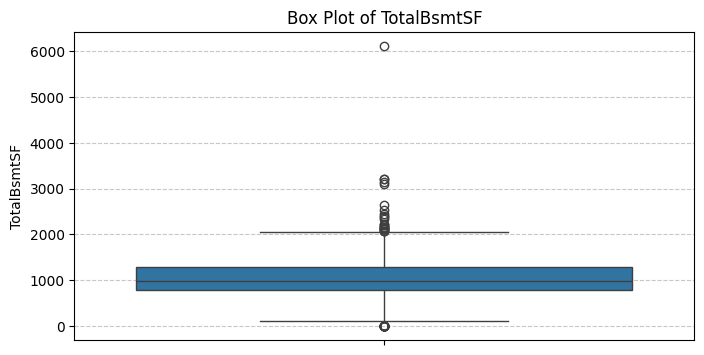

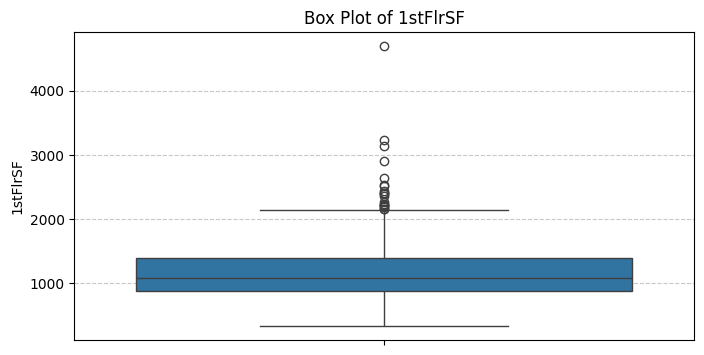

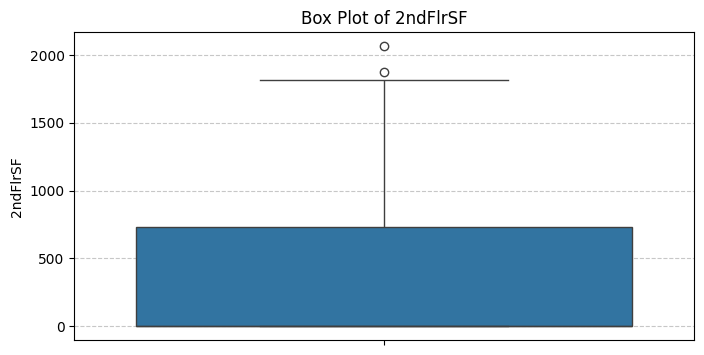

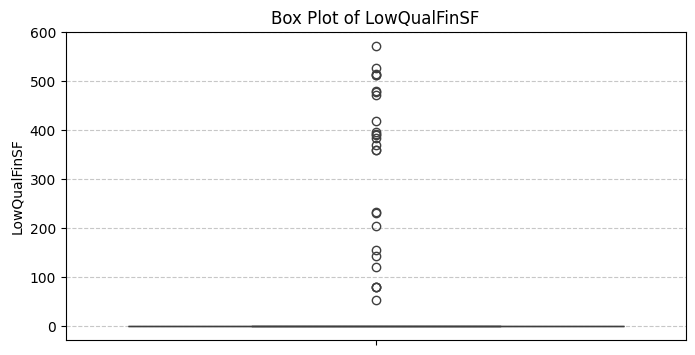

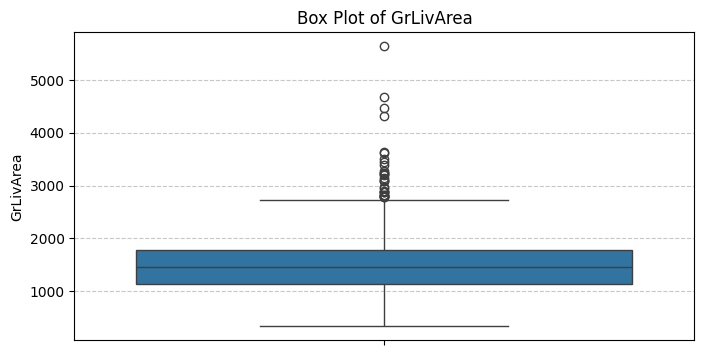

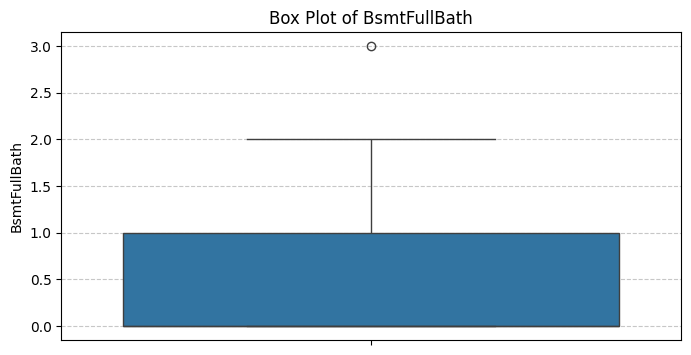

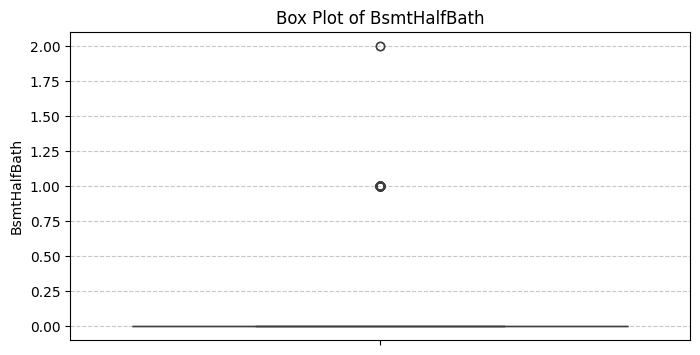

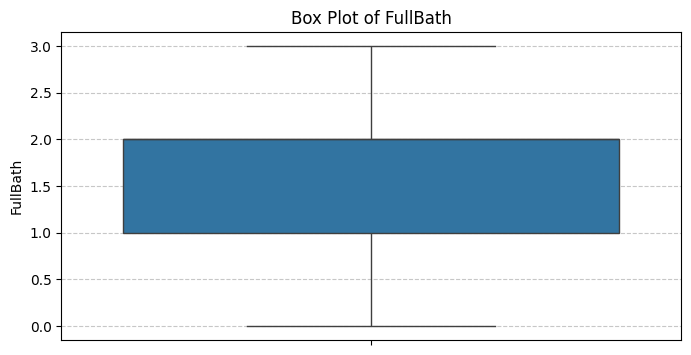

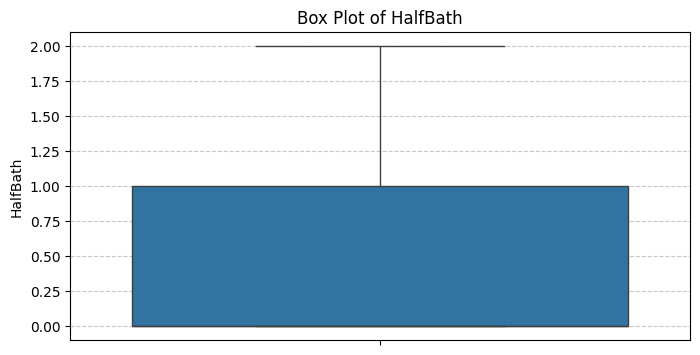

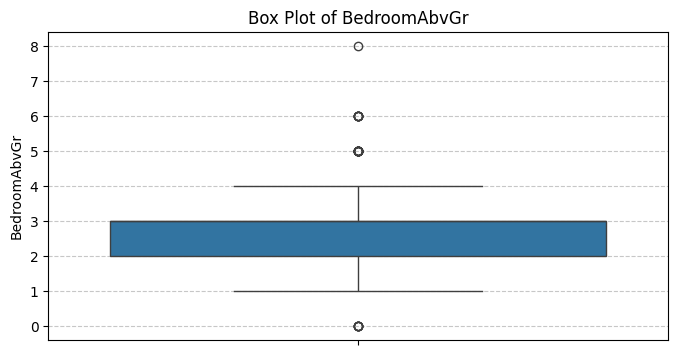

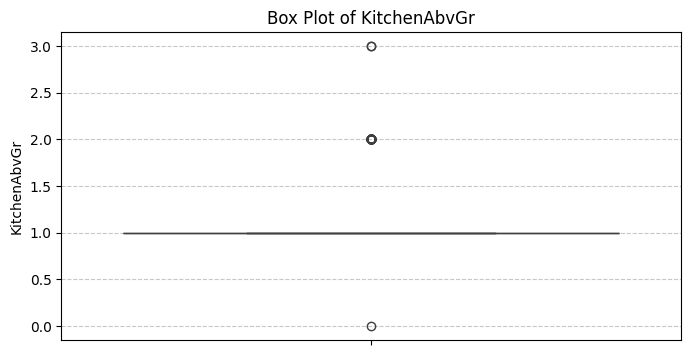

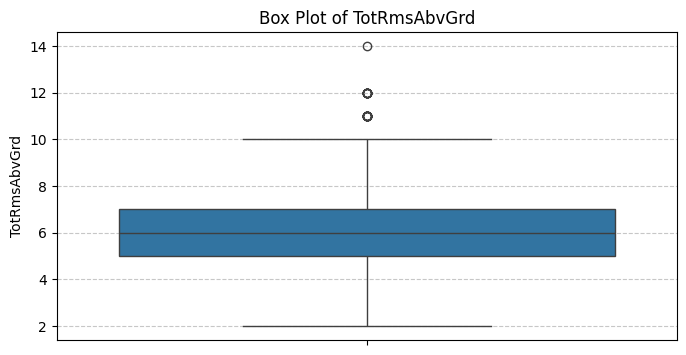

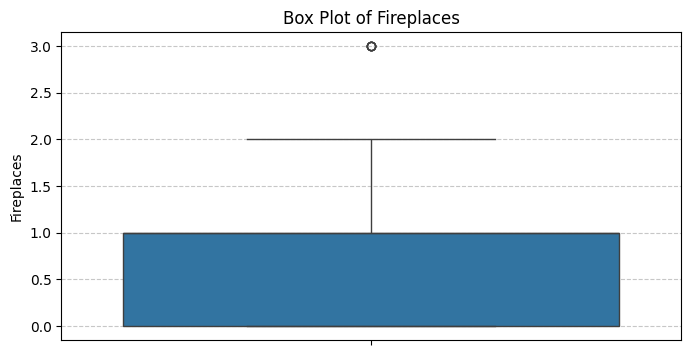

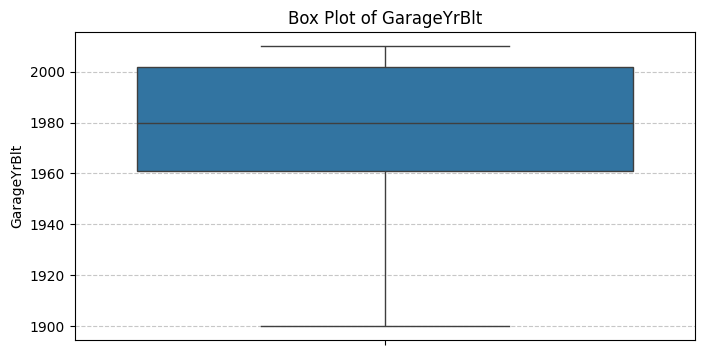

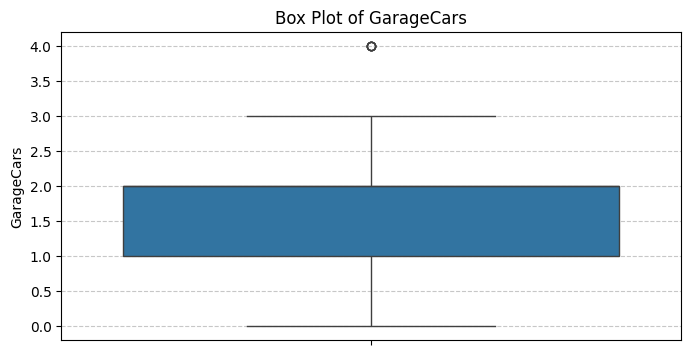

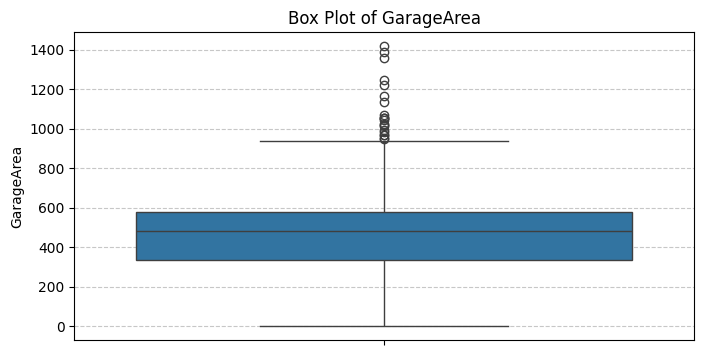

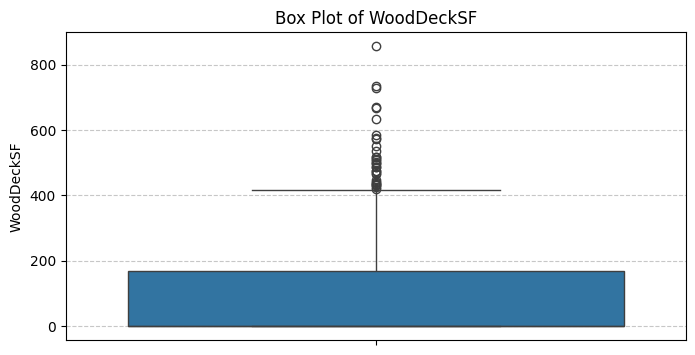

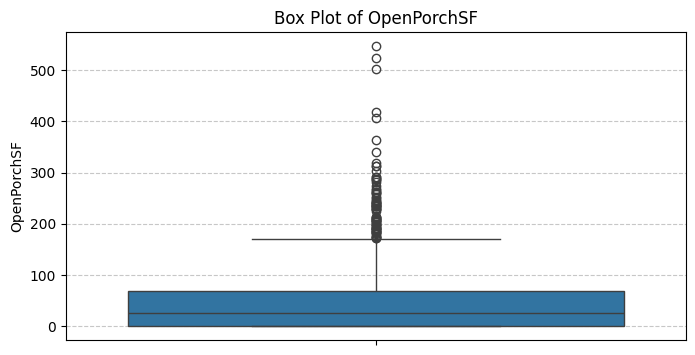

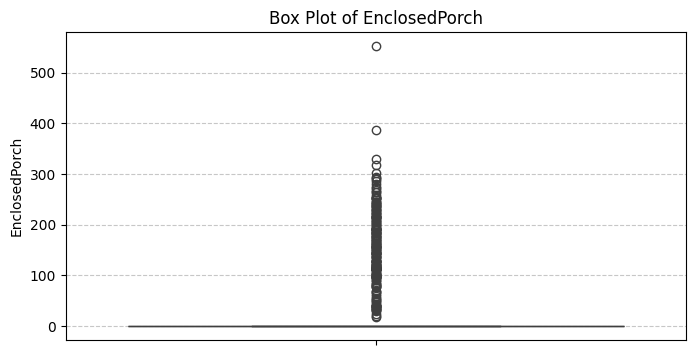

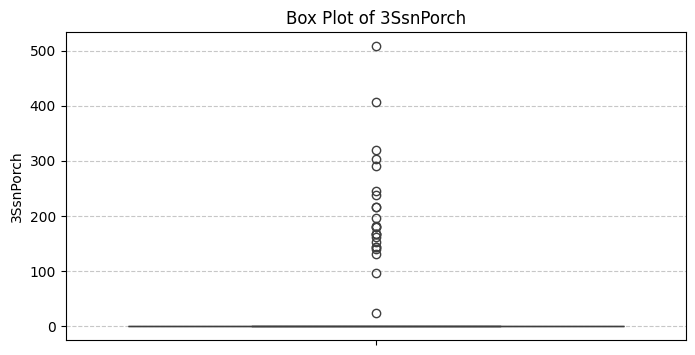

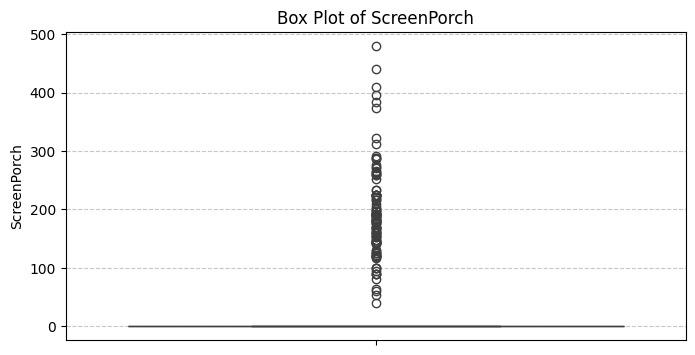

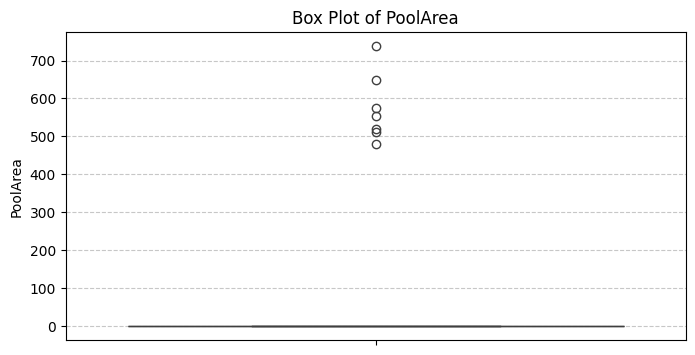

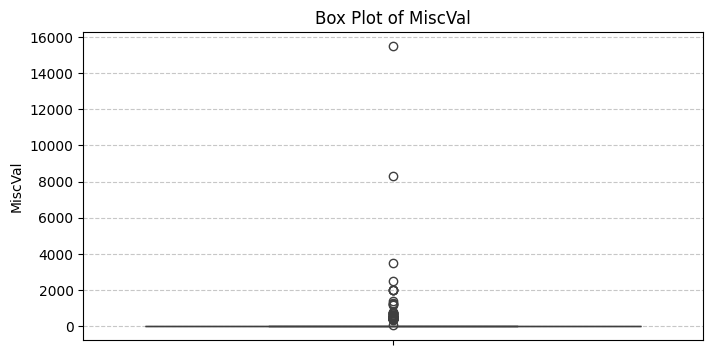

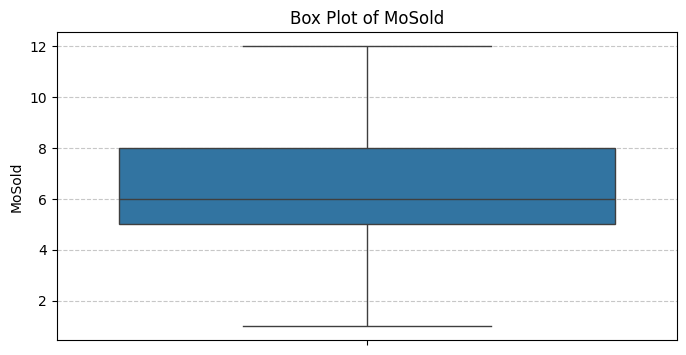

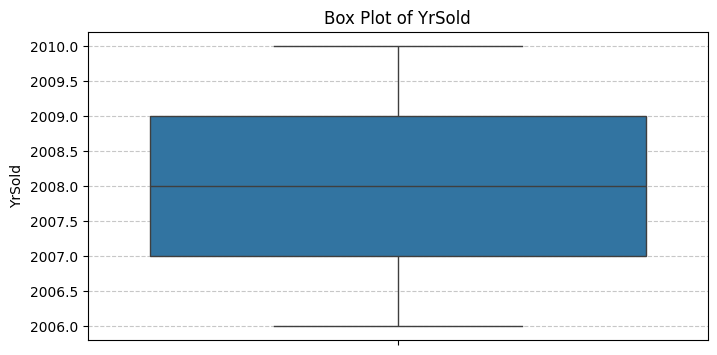

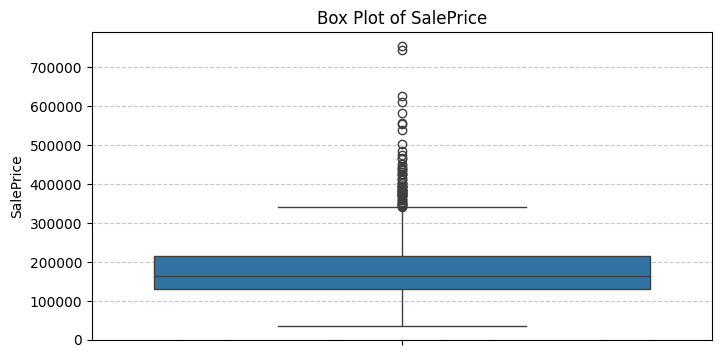

In [12]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

#Cleaning

In [13]:
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence','Id']
df = df.drop(columns=columns_to_drop)

In [14]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [15]:
basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in basement_cols:
    df[col] = df[col].fillna('NoBsmt')

# impute categorical garage features with "NoGarage"
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in garage_cols:
    df[col] = df[col].fillna('NoGarage')

# impute numerical garage features with 0
numeric_garage_cols = ['GarageCars', 'GarageArea', 'GarageYrBlt']
for col in numeric_garage_cols:
    df[col] = df[col].fillna(0)

# Impute fireplace feature with "NoFireplace"
df['FireplaceQu'] = df['FireplaceQu'].fillna('NoFireplace')

# Impute MasVnrType with "None" and MasVnrArea with 0 because it
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

In [16]:
df.isnull().sum().sort_values(ascending=False)

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


#Outliers Handling

In [17]:
cols = [
    'GarageArea', '1stFlrSF', 'LotArea', 'TotalBsmtSF', 'GrLivArea',
    'LotFrontage','MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
    'ScreenPorch', 'PoolArea', 'MiscVal', '2ndFlrSF', 'LowQualFinSF'
]

for col in cols:
    df[col] = np.log1p(df[col])

#Encoding

In [18]:
encoders = {}
obj_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


#Feature Selection

In [19]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.695147
GarageCars,0.640409
1stFlrSF,0.591299
...,...
GarageType,-0.415283
GarageFinish,-0.425684
KitchenQual,-0.589189
BsmtQual,-0.593734


In [20]:
corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix['SalePrice']
selected_features = target_corr[abs(target_corr) > 0.5].index.tolist()

if 'SalePrice' in selected_features:
    selected_features.remove('SalePrice')

print("Selected Features:", selected_features)

Selected Features: ['OverallQual', 'YearBuilt', 'YearRemodAdd', 'ExterQual', 'BsmtQual', '1stFlrSF', 'GrLivArea', 'FullBath', 'KitchenQual', 'TotRmsAbvGrd', 'GarageCars']


In [21]:
features = [
    'OverallQual', 'YearBuilt',
    'YearRemodAdd', 'ExterQual',
    'BsmtQual', '1stFlrSF',
    'GrLivArea','FullBath',
    'KitchenQual','TotRmsAbvGrd',
    'GarageType', 'GarageCars']

In [22]:
pd.DataFrame(df[features]).to_csv('features.csv', index=False)

#Linear Regression Model

In [23]:
X = df[features]
y = df['SalePrice']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_train_pred_lr = model_lr.predict(X_train)
y_test_pred_lr = model_lr.predict(X_test)
print(f"Linear Regression Training R²: {r2_score(y_train, y_train_pred_lr):.4f}")
print(f"Linear Regression Test R²: {r2_score(y_test, y_test_pred_lr):.4f}\n")
print(f"Test MSE Error: {(mean_squared_error(y_test, y_test_pred_lr)):.4f}")
print(f"Test MAE Error: {mean_absolute_error(y_test, y_test_pred_lr):.4f}\n")

Linear Regression Training R²: 0.7792
Linear Regression Test R²: 0.7858

Test MSE Error: 1643231093.0477
Test MAE Error: 25493.1502



#Scaled Linear Regression  

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_train_pred_lr = model_lr.predict(X_train_scaled)
y_test_pred_lr = model_lr.predict(X_test_scaled)
print(f"Scaled Linear Regression Training R²: {r2_score(y_train, y_train_pred_lr):.4f}")
print(f"Scaled Linear Regression Test R²: {r2_score(y_test, y_test_pred_lr):.4f}\n")
print(f"Test MSE Error: {(mean_squared_error(y_test, y_test_pred_lr)):.4f}")
print(f"Test MAE Error: {mean_absolute_error(y_test, y_test_pred_lr):.4f}\n")

Scaled Linear Regression Training R²: 0.7792
Scaled Linear Regression Test R²: 0.7858

Test MSE Error: 1643231093.0477
Test MAE Error: 25493.1502



#Ridge

In [28]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)
print(f"Ridge (L2) Training R²: {r2_score(y_train, y_train_pred_ridge):.4f}")
print(f"Ridge (L2) Test R²: {r2_score(y_test, y_test_pred_ridge):.4f}\n")
print(f"Test MSE Error: {(mean_squared_error(y_test, y_test_pred_ridge)):.4f}")
print(f"Test MAE Error: {mean_absolute_error(y_test, y_test_pred_ridge):.4f}\n")

Ridge (L2) Training R²: 0.7792
Ridge (L2) Test R²: 0.7858

Test MSE Error: 1643242924.7692
Test MAE Error: 25492.9432



#Lasso

In [29]:
lasso_model = Lasso(alpha=0.005)
lasso_model.fit(X_train_scaled, y_train)
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)
print(f"Lasso (L1) Training R²: {r2_score(y_train, y_train_pred_lasso):.4f}")
print(f"Lasso (L1) Test R²: {r2_score(y_test, y_test_pred_lasso):.4f}")
print(f"Test MSE Error: {(mean_squared_error(y_test, y_test_pred_lasso)):.4f}")
print(f"Test MAE Error: {mean_absolute_error(y_test, y_test_pred_lasso):.4f}\n")

Lasso (L1) Training R²: 0.7792
Lasso (L1) Test R²: 0.7858
Test MSE Error: 1643231109.5057
Test MAE Error: 25493.1491

